### Import / Config

In [1]:
import pandas as pd
from sqlalchemy import create_engine, text
import cred_pg as c

# None = unbegrenzt
pd.set_option("display.max_rows", 50)
pd.set_option("display.max_columns", None)


In [2]:
engine = create_engine(
    f'postgresql://{c.pg_userid}:{c.pg_password}@{c.pg_host}/{c.pg_db}', 
    connect_args = {
        'options': '-c search_path=$user,ugeobln,umisc,umobility,usozmed,public', 
        'keepalives_idle': 120
    },
    pool_size=1, 
    max_overflow=0,
    execution_options={ 'isolation_level': 'AUTOCOMMIT' }
)

### Basis

In [3]:
sql = """
SELECT sales_month, kind_of_business, sales
FROM retail_sales
ORDER BY 1
;
"""
with engine.connect() as con:
    df = pd.read_sql_query(text(sql), con)
df

,sales_month,kind_of_business,sales
0,1992-01-01,New car dealers,24056.0
1,1992-01-01,Used car dealers,1744.0
2,1992-01-01,"Automotive parts, acc., and tire stores",3023.0
3,1992-01-01,Furniture and home furnishings stores,3846.0
4,1992-01-01,"Furniture, home furn, electronics, and applian...",7503.0
...,...,...,...
22615,2020-12-01,GAFO(1),144871.0
22616,2020-12-01,Retail sales and food services excl motor vehi...,494937.0
22617,2020-12-01,"Retail and food services sales, total",611429.0
22618,2020-12-01,Retail sales and food services excl gasoline s...,574794.0


In [4]:
sql = """
select kind_of_business, count(*) as anz
FROM retail_sales
group by 1
ORDER BY 1
;
"""
with engine.connect() as con:
    df = pd.read_sql_query(text(sql), con)
df 

,kind_of_business,anz
0,All other gen. merchandise stores,348
1,All other home furnishings stores,348
2,Automobile and other motor vehicle dealers,348
3,Automobile dealers,348
4,"Automotive parts, acc., and tire stores",348
...,...,...
60,Supermarkets and other grocery (except conveni...,348
61,Used car dealers,348
62,Used merchandise stores,348
63,Warehouse clubs and superstores,348


### Mit Lösung

#### 1

In [19]:
sql = """
select sales_month, sales
from retail_sales
where kind_of_business = 'Retail and food services sales, total'
order by sales_month
"""
with engine.connect() as con:
    df = pd.read_sql_query(text(sql), con)
# df

<Axes: xlabel='sales_month', ylabel='Dollar (million)'>

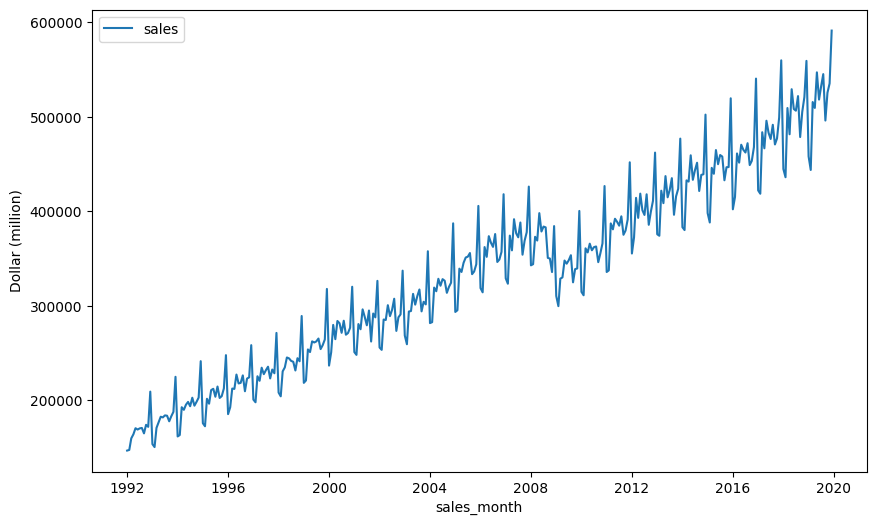

In [20]:
df.set_index('sales_month').plot(
    figsize=(10,6),
    ylabel="Dollar (million)", 
    legend=True
)

#### 2

In [22]:
sql = """
select date_part('year',sales_month) as sales_year, sum(sales) as sales
from retail_sales
where kind_of_business = 'Retail and food services sales, total'
group by 1
order by 1
"""
with engine.connect() as con:
    df = pd.read_sql_query(text(sql), con)
# df

<Axes: xlabel='sales_year', ylabel='Dollar (million)'>

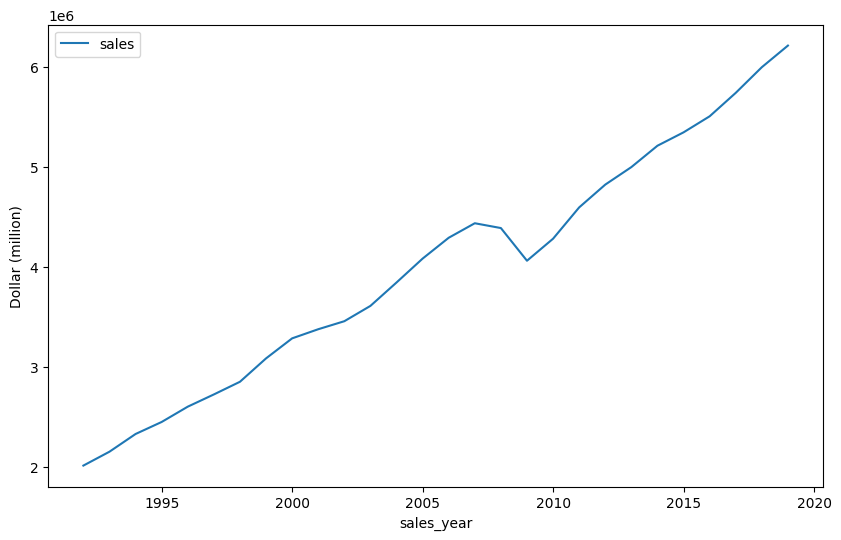

In [23]:
df.set_index('sales_year').plot(
    figsize=(10,6),
    ylabel="Dollar (million)", 
    legend=True
)

#### 3

In [25]:
sql = """
select 
  date_part('year',sales_month) as sales_year,
  kind_of_business,
  sum(sales) as sales
from retail_sales
where kind_of_business in ('Book stores','Sporting goods stores','Hobby, toy, and game stores')
group by 1,2
order by 1,2
"""
with engine.connect() as con:
    df = pd.read_sql_query(text(sql), con)
# df

<Axes: xlabel='sales_year', ylabel='sales, Dollar (million)'>

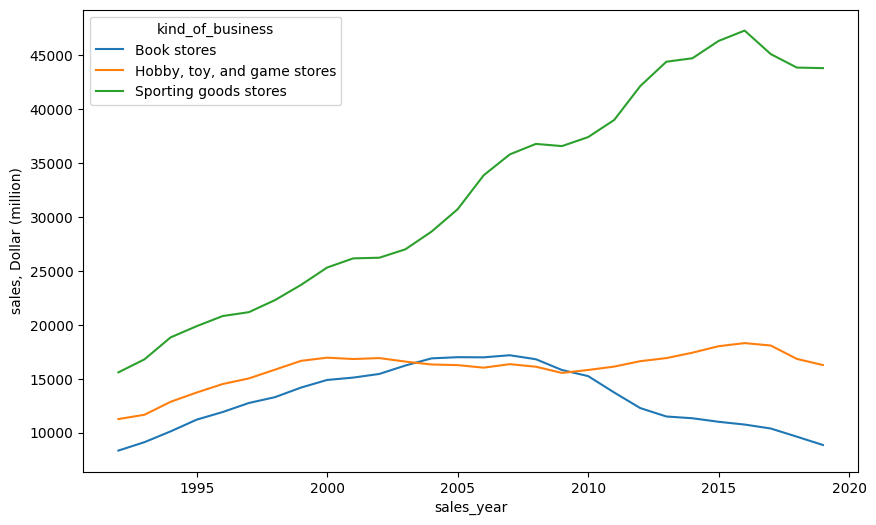

In [26]:
df.pivot(index='sales_year', columns='kind_of_business', values='sales').plot(
    figsize=(10,6),
    ylabel="sales, Dollar (million)"
)

#### 4

In [27]:
sql = """
select 
  cast(date_part('year',sales_month) as integer) as sales_year,
  kind_of_business,
  sum(sales) as sales
from retail_sales
where kind_of_business in ('Men''s clothing stores','Women''s clothing stores')
group by 1,2
order by 1
"""
with engine.connect() as con:
    df = pd.read_sql_query(text(sql), con)
# df

<Axes: xlabel='sales_year', ylabel='sales, Dollar (million)'>

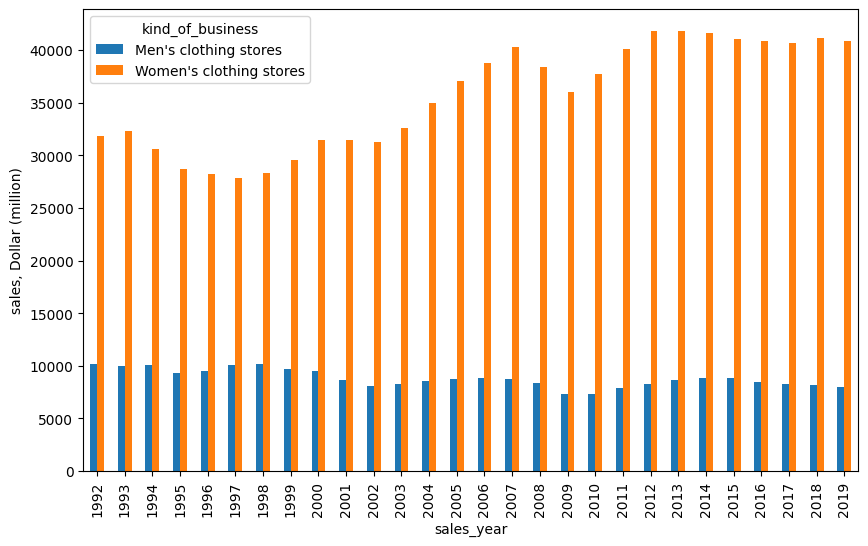

In [28]:
df.pivot(index='sales_year', columns='kind_of_business', values='sales').plot.bar(
    figsize=(10,6),
    ylabel="sales, Dollar (million)", 
)

### Ohne Lösung

#### 5

In [ ]:
sql = """
select 'dummy' as dummy
"""
with engine.connect() as con:
    df = pd.read_sql_query(text(sql), con)
# df

In [ ]:
# Visualization

#### 6

In [ ]:
sql = """
select 'dummy' as dummy
"""
with engine.connect() as con:
    df = pd.read_sql_query(text(sql), con)
# df

In [ ]:
# Visualization

#### 7

In [ ]:
sql = """
select 'dummy' as dummy
"""
with engine.connect() as con:
    df = pd.read_sql_query(text(sql), con)
df

In [ ]:
# Visualization

#### 8

In [ ]:
sql = """
select 'dummy' as dummy
"""
with engine.connect() as con:
    df = pd.read_sql_query(text(sql), con)
df

In [ ]:
# Visualization

#### 9

In [ ]:
sql = """
select 'dummy' as dummy
"""
with engine.connect() as con:
    df = pd.read_sql_query(text(sql), con)
df

In [ ]:
# Visualization

#### 10

In [ ]:
sql = """
select 'dummy' as dummy
"""
with engine.connect() as con:
    df = pd.read_sql_query(text(sql), con)
df

In [ ]:
# Visualization

#### 11

In [ ]:
sql = """
select 'dummy' as dummy
"""
with engine.connect() as con:
    df = pd.read_sql_query(text(sql), con)
df

In [ ]:
# Visualization

#### 12

In [ ]:
sql = """
select 'dummy' as dummy
"""
with engine.connect() as con:
    df = pd.read_sql_query(text(sql), con)
df

In [ ]:
# Visualization

#### 13

In [ ]:
sql = """
select 'dummy' as dummy
"""
with engine.connect() as con:
    df = pd.read_sql_query(text(sql), con)
df